In [1]:
# Google Drive mounten
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ZELLE 1: SETUP UND GITHUB PULL
import os
from google.colab import userdata

# Installiere benötigte Bibliotheken
!pip install -q rasterio torchmetrics

# --- GITHUB KONFIGURATION ---
GITHUB_USER = "MagicMorgigi"      # <-- Anpassen
REPO_NAME = "master_thesis_FM"          # <-- Anpassen
BRANCH = "main"                     # <-- Anpassen

# Hole PAT aus Colab Secrets
PAT = userdata.get('MA_colab_github_PAT')

REPO_PATH = f"/content/drive/MyDrive/{REPO_NAME}" # <-- Anpassen
os.chdir(REPO_PATH)
print(f"Aktuelles Verzeichnis: {os.getcwd()}")

# Git konfigurieren und pullen (kein Klonen)
!git config --global user.email "f.morgalla@campus.tu-berlin.de"
!git config --global user.name "FM"
!git fetch origin
!git checkout {BRANCH}
!git pull origin {BRANCH}
print(f"Aktuelle Änderungen vom Branch '{BRANCH}' erfolgreich gezogen.")

KeyboardInterrupt: 

In [ ]:
# ZELLE 2: IMPORTS UND SEEDING
!pip install -q torchmetrics rasterio

import os
import gc
import re
import csv
import time
import torch
import shutil
import rasterio
import subprocess
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from glob import glob
from tqdm.auto import tqdm
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torchmetrics import MeanSquaredError, MeanAbsoluteError, R2Score

def seed_everything(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Globaler Seed gesetzt auf: {seed}")
SEED = 42
seed_everything(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.8 MB/s eta 0:00:00
Globaler Seed gesetzt auf: 42


In [ ]:
# ZELLE 3: KONFIGURATION
@dataclass(frozen=True)
class Config:
    # Google Drive Archiv-Pfade

    DRIVE_ROOT: str = "/content/drive/MyDrive/master_thesis_FM/datasets/BioMassters/packed_compressed_data/tar_gz_archives"

    DRIVE_FEAT_TRAIN: str = f"{DRIVE_ROOT}/AnySat_embedded_dense_features/6%_subset/train.tar.gz"
    DRIVE_FEAT_VAL: str = f"{DRIVE_ROOT}/AnySat_embedded_dense_features/6%_subset/val.tar.gz"
    DRIVE_FEAT_TEST: str = f"{DRIVE_ROOT}/AnySat_embedded_dense_features/6%_subset/test.tar.gz"
    DRIVE_LAB_TRAIN: str = f"{DRIVE_ROOT}/labels/6%_subset/train.tar.gz"
    DRIVE_LAB_VAL: str = f"{DRIVE_ROOT}/labels/6%_subset/val.tar.gz"
    DRIVE_LAB_TEST: str = f"{DRIVE_ROOT}/labels/6%_subset/test.tar.gz"

    LOCAL_DATA_DIR: str = "/content/local_data"

    # Training Parameter
    IN_CHANNELS: int = 1536
    BATCH_SIZE: int = 1
    NUM_WORKERS: int = 2     # Auf 0 gesetzt, um RAM-Leaks durch Multiprocessing zu verhindern
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY: float = 1e-3
    MAX_EPOCHS: int = 200
    PATIENCE: int = 10
    PATCH_SIZE: int = 40
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"

    EXP_NAME = f"AS_LP_DENSE_patchSize{PATCH_SIZE}_6%subset_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_WD{str(WEIGHT_DECAY).split('.')[1]}_EP{MAX_EPOCHS}_PAT{PATIENCE}_SEED{SEED}_L4"
    # Output Paths
    OUTPUT_DIR: str = f"/content/drive/MyDrive/master_thesis_FM/experiments/AnySat/linear_probing/dense_features/{EXP_NAME}"

CONFIG = Config()
os.makedirs(CONFIG.OUTPUT_DIR, exist_ok=False)
print(f"Konfiguration geladen. Ziel-Gerät: {CONFIG.DEVICE}")

Konfiguration geladen. Ziel-Gerät: cuda


In [ ]:
# ZELLE 4: DATENTRANSFER UND EXTRAKTION
def extract_archive_sequentially(drive_path: str, target_dir: str):
    """Kopiert, entpackt und löscht Archive sequenziell für minimalen SSD-Verbrauch."""
    if os.path.exists(target_dir) and len(os.listdir(target_dir)) > 0:
        print(f"Daten bereits in {target_dir} vorhanden. Überspringe Extraktion.")
        return

    os.makedirs(target_dir, exist_ok=True)
    archive_name = os.path.basename(drive_path)
    local_archive_path = os.path.join(CONFIG.LOCAL_DATA_DIR, archive_name)

    print(f"Kopiere {archive_name}...")
    shutil.copy(drive_path, local_archive_path)

    print(f"Entpacke {archive_name}...")
    subprocess.run(["tar", "-xzf", local_archive_path, "-C", target_dir], check=True)

    print(f"Lösche lokales Archiv {local_archive_path}...\n")
    os.remove(local_archive_path)

local_paths = {
    'feat_train': os.path.join(CONFIG.LOCAL_DATA_DIR, 'feat_train'),
    'feat_val': os.path.join(CONFIG.LOCAL_DATA_DIR, 'feat_val'),
    'feat_test': os.path.join(CONFIG.LOCAL_DATA_DIR, 'feat_test'),
    'lab_train': os.path.join(CONFIG.LOCAL_DATA_DIR, 'lab_train'),
    'lab_val': os.path.join(CONFIG.LOCAL_DATA_DIR, 'lab_val'),
    'lab_test': os.path.join(CONFIG.LOCAL_DATA_DIR, 'lab_test')
}

extract_archive_sequentially(CONFIG.DRIVE_FEAT_TRAIN, local_paths['feat_train'])
extract_archive_sequentially(CONFIG.DRIVE_FEAT_VAL, local_paths['feat_val'])
extract_archive_sequentially(CONFIG.DRIVE_FEAT_TEST, local_paths['feat_test'])
extract_archive_sequentially(CONFIG.DRIVE_LAB_TRAIN, local_paths['lab_train'])
extract_archive_sequentially(CONFIG.DRIVE_LAB_VAL, local_paths['lab_val'])
extract_archive_sequentially(CONFIG.DRIVE_LAB_TEST, local_paths['lab_test'])

Kopiere train.tar.gz...
Entpacke train.tar.gz...
Lösche lokales Archiv /content/local_data/train.tar.gz...

Kopiere val.tar.gz...
Entpacke val.tar.gz...
Lösche lokales Archiv /content/local_data/val.tar.gz...

Kopiere test.tar.gz...
Entpacke test.tar.gz...
Lösche lokales Archiv /content/local_data/test.tar.gz...

Kopiere train.tar.gz...
Entpacke train.tar.gz...
Lösche lokales Archiv /content/local_data/train.tar.gz...

Kopiere val.tar.gz...
Entpacke val.tar.gz...
Lösche lokales Archiv /content/local_data/val.tar.gz...

Kopiere test.tar.gz...
Entpacke test.tar.gz...
Lösche lokales Archiv /content/local_data/test.tar.gz...



In [ ]:
# ZELLE 5: DATASET UND DATALOADERS
class BiomassDataset(Dataset):
    def __init__(self, feat_dir: str, lab_dir: str):
        self.feat_paths = glob(os.path.join(feat_dir, "**/*.pt"), recursive=True)
        self.samples = []
        feat_pattern = re.compile(r'_([A-Za-z0-9]{8})_S1_10\.pt$')

        for f_path in self.feat_paths:
            # Einfacher Sicherheitscheck gegen Metadaten-Files
            if os.path.getsize(f_path) < 100_000_000:
                continue

            match = feat_pattern.search(os.path.basename(f_path))
            if match:
                file_id = match.group(1)
                expected_lab = os.path.join(lab_dir, f"{file_id}_agbm.tif")
                if os.path.exists(expected_lab):
                    self.samples.append((f_path, expected_lab, file_id))

        print(f"{len(self.samples)} Feature-Label-Paare aus {feat_dir} gemappt.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        f_path, l_path, file_id = self.samples[idx]

        # 1. Feature laden und auf [1536, 256, 256] standardisieren
        feat = torch.load(f_path, map_location='cpu')

        if feat.is_sparse:
            feat = feat.to_dense()

        feat = feat.to(torch.float32)

        # Erwartet standardmäßig [256, 256, 1536] vom Extraktor
        if feat.dim() == 3 and feat.shape == (256, 256, 1536):
            feat = feat.permute(2, 0, 1)
        elif feat.dim() == 3 and feat.shape == (1536, 256, 256):
            pass
        else:
            # Fallback/Error falls sich doch ein Bug einschleicht
            feat = feat.reshape(256, 256, 1536).permute(2, 0, 1)

        # 2. Label laden via rasterio
        with rasterio.open(l_path) as src:
            lab = src.read(1)
            lab = torch.from_numpy(lab).to(torch.float32).unsqueeze(0)

        return feat, lab, file_id

train_ds = BiomassDataset(local_paths['feat_train'], local_paths['lab_train'])
val_ds = BiomassDataset(local_paths['feat_val'], local_paths['lab_val'])
test_ds = BiomassDataset(local_paths['feat_test'], local_paths['lab_test'])

# pin_memory=False schützt vor RAM-Spikes bei sehr großen Tensoren
train_loader = DataLoader(train_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=True, num_workers=CONFIG.NUM_WORKERS, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=False, num_workers=CONFIG.NUM_WORKERS, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=False, num_workers=CONFIG.NUM_WORKERS, pin_memory=False)

417 Feature-Label-Paare aus /content/local_data/feat_train gemappt.
105 Feature-Label-Paare aus /content/local_data/feat_val gemappt.
167 Feature-Label-Paare aus /content/local_data/feat_test gemappt.


In [ ]:
# ZELLE 6: LINEAR PROBE MODELL UND METRIKEN
class LinearProbe(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # 1x1 Conv führt eine lineare Transformation unabhängig pro Pixel aus
        self.probe = nn.Conv2d(in_channels, 1, kernel_size=1, bias=True)

    def forward(self, x):
        return self.probe(x)

model = LinearProbe(in_channels=CONFIG.IN_CHANNELS).to(CONFIG.DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG.LEARNING_RATE, weight_decay=CONFIG.WEIGHT_DECAY)

train_mse = MeanSquaredError().to(CONFIG.DEVICE)
val_mse = MeanSquaredError().to(CONFIG.DEVICE)
val_rmse = MeanSquaredError(squared=False).to(CONFIG.DEVICE)
val_mae = MeanAbsoluteError().to(CONFIG.DEVICE)
val_r2 = R2Score().to(CONFIG.DEVICE)

Epoch 1/200 [Train]:   0%|          | 0/417 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Epoch 1/200 [Val]:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 1 -> Train MSE: 5534.3623 | Val MSE: 5034.8892 | Val R2: 0.1256
-> Bestes Modell gespeichert!


Epoch 2/200 [Train]:   0%|          | 0/417 [00:00<?, ?it/s]

...

Epoch 121/200 [Val]:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 121 -> Train MSE: 3442.2776 | Val MSE: 3948.7200 | Val R2: 0.3142


Epoch 122/200 [Train]:   0%|          | 0/417 [00:00<?, ?it/s]

Epoch 122/200 [Val]:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 122 -> Train MSE: 3440.5344 | Val MSE: 3927.3191 | Val R2: 0.3179
Early Stopping ausgelöst nach 122 Epochen.


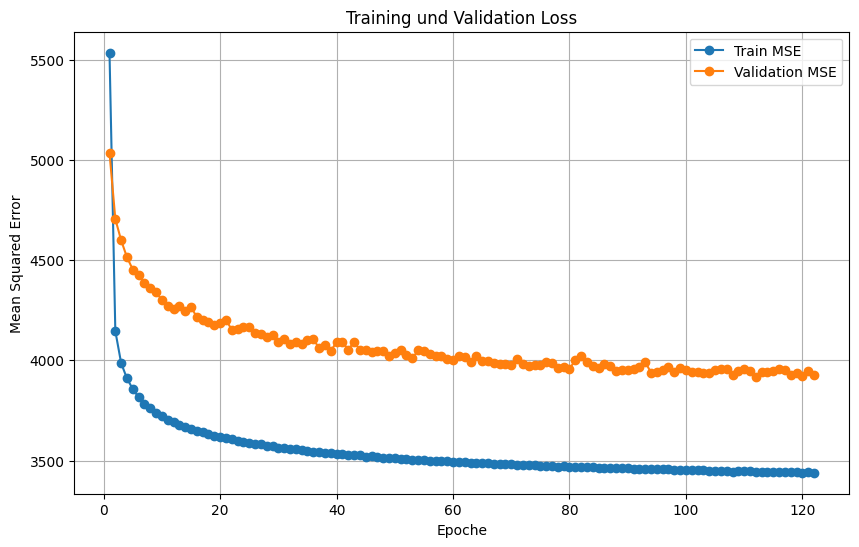

In [ ]:
# ZELLE 7: TRAINING LOOP
checkpoint_path = os.path.join(CONFIG.OUTPUT_DIR, "checkpoint.pth")
history_path = os.path.join(CONFIG.OUTPUT_DIR, "training_history.csv")
best_model_path = os.path.join(CONFIG.OUTPUT_DIR, "best_linear_probe.pth")

start_epoch = 0
best_val_loss = float('inf')
patience_counter = 0
history = []

# Checkpoint laden, falls Training unterbrochen wurde
if os.path.exists(checkpoint_path):
    print("Bestehenden Checkpoint gefunden. Setze Training fort...")
    ckpt = torch.load(checkpoint_path, map_location=CONFIG.DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch'] + 1
    best_val_loss = ckpt['best_val_loss']
    patience_counter = ckpt['patience_counter']
    if os.path.exists(history_path):
        history = pd.read_csv(history_path).to_dict('records')

# Historie initialisieren
if not os.path.exists(history_path):
    with open(history_path, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Epoch', 'Train_MSE', 'Val_MSE', 'Val_RMSE', 'Val_MAE', 'Val_R2'])

for epoch in range(start_epoch, CONFIG.MAX_EPOCHS):
    model.train()
    train_mse.reset()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG.MAX_EPOCHS} [Train]")
    for feats, labs, _ in pbar:
        feats, labs = feats.to(CONFIG.DEVICE), labs.to(CONFIG.DEVICE)

        optimizer.zero_grad()
        preds = model(feats)

        loss = torch.nn.functional.mse_loss(preds.view(-1), labs.view(-1))
        loss.backward()
        optimizer.step()

        train_mse.update(preds.view(-1), labs.view(-1))
        pbar.set_postfix({'MSE': f"{loss.item():.4f}"})

    epoch_train_mse = train_mse.compute().item()

    # Validation
    model.eval()
    val_mse.reset()
    val_rmse.reset()
    val_mae.reset()
    val_r2.reset()

    with torch.no_grad():
        for feats, labs, _ in tqdm(val_loader, desc=f"Epoch {epoch+1}/{CONFIG.MAX_EPOCHS} [Val]", leave=False):
            feats, labs = feats.to(CONFIG.DEVICE), labs.to(CONFIG.DEVICE)
            preds = model(feats)

            p_flat, l_flat = preds.view(-1), labs.view(-1)
            val_mse.update(p_flat, l_flat)
            val_rmse.update(p_flat, l_flat)
            val_mae.update(p_flat, l_flat)
            val_r2.update(p_flat, l_flat)

    epoch_val_mse = val_mse.compute().item()
    epoch_val_rmse = val_rmse.compute().item()
    epoch_val_mae = val_mae.compute().item()
    epoch_val_r2 = val_r2.compute().item()

    print(f"Epoch {epoch+1} -> Train MSE: {epoch_train_mse:.4f} | Val MSE: {epoch_val_mse:.4f} | Val R2: {epoch_val_r2:.4f}")

    # Historie loggen
    row = {'Epoch': epoch+1, 'Train_MSE': epoch_train_mse, 'Val_MSE': epoch_val_mse, 'Val_RMSE': epoch_val_rmse, 'Val_MAE': epoch_val_mae, 'Val_R2': epoch_val_r2}
    history.append(row)
    with open(history_path, mode='a', newline='') as f:
        csv.DictWriter(f, fieldnames=row.keys()).writerow(row)

    # Checkpointing & Early Stopping
    ckpt_state = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_loss': best_val_loss,
        'patience_counter': patience_counter
    }

    if epoch_val_mse < best_val_loss:
        best_val_loss = epoch_val_mse
        patience_counter = 0
        ckpt_state['best_val_loss'] = best_val_loss
        ckpt_state['patience_counter'] = 0
        torch.save(model.state_dict(), best_model_path)
        print("-> Bestes Modell gespeichert!")
    else:
        patience_counter += 1

    torch.save(ckpt_state, checkpoint_path)

    # Garbage Collection forciert
    gc.collect()
    torch.cuda.empty_cache()

    if patience_counter >= CONFIG.PATIENCE:
        print(f"Early Stopping ausgelöst nach {epoch+1} Epochen.")
        break

# Lernkurven plotten
df = pd.read_csv(history_path)
plt.figure(figsize=(10, 6))
plt.plot(df['Epoch'], df['Train_MSE'], label='Train MSE', marker='o')
plt.plot(df['Epoch'], df['Val_MSE'], label='Validation MSE', marker='o')
plt.title('Training und Validation Loss')
plt.xlabel('Epoche')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(CONFIG.OUTPUT_DIR, 'loss_curve.png'))
plt.show()

In [ ]:
# ZELLE 8: INFERENZ AUF TESTDATEN
best_model_path = os.path.join(CONFIG.OUTPUT_DIR, "best_linear_probe.pth")
if not os.path.exists(best_model_path):
    raise FileNotFoundError("Bestes Modell nicht gefunden. Bitte zuerst trainieren.")

model.load_state_dict(torch.load(best_model_path, map_location=CONFIG.DEVICE))
model.eval()

test_mse = MeanSquaredError().to(CONFIG.DEVICE)
test_rmse = MeanSquaredError(squared=False).to(CONFIG.DEVICE)
test_mae = MeanAbsoluteError().to(CONFIG.DEVICE)
test_r2 = R2Score().to(CONFIG.DEVICE)

viz_samples = []

print("Starte Inferenz auf dem Test-Set...")
with torch.no_grad():
    for i, (feats, labs, ids) in enumerate(tqdm(test_loader, desc="Testing")):
        feats, labs = feats.to(CONFIG.DEVICE), labs.to(CONFIG.DEVICE)
        preds = model(feats)

        p_flat, l_flat = preds.view(-1), labs.view(-1)
        test_mse.update(p_flat, l_flat)
        test_rmse.update(p_flat, l_flat)
        test_mae.update(p_flat, l_flat)
        test_r2.update(p_flat, l_flat)

        # Erste Batch für Visualisierung speichern
        if i == 0:
            for b in range(min(4, feats.size(0))):
                viz_samples.append({
                    'id': ids[b],
                    'target': labs[b].cpu().squeeze().numpy(),
                    'pred': preds[b].cpu().squeeze().numpy()
                })

final_metrics = {
    'Test_MSE': test_mse.compute().item(),
    'Test_RMSE': test_rmse.compute().item(),
    'Test_MAE': test_mae.compute().item(),
    'Test_R2': test_r2.compute().item()
}

metrics_out_path = os.path.join(CONFIG.OUTPUT_DIR, 'test_metrics.txt')
with open(metrics_out_path, 'w') as f:
    f.write("--- BEST MODEL METRICS ---\n")
    for k, v in final_metrics.items():
        f.write(f"{k}: {v:.4f}\n")
    print(final_metrics)

# Visualisierung (2 Spalten: Target vs Pred)
fig, axes = plt.subplots(len(viz_samples), 2, figsize=(10, 4 * len(viz_samples)))
if len(viz_samples) == 1:
    axes = [axes] # Fallback für Batch Size 1

for idx, sample in enumerate(viz_samples):
    vmin = min(sample['target'].min(), sample['pred'].min())
    vmax = max(sample['target'].max(), sample['pred'].max())

    im1 = axes[idx][0].imshow(sample['target'], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[idx][0].set_title(f"Target AGB - ID: {sample['id']}")
    axes[idx][0].axis('off')

    im2 = axes[idx][1].imshow(sample['pred'], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[idx][1].set_title(f"Predicted AGB - ID: {sample['id']}")
    axes[idx][1].axis('off')

fig.colorbar(im1, ax=[ax for row in axes for ax in row], orientation='horizontal', fraction=0.02, pad=0.04, label='AGB (tons)')
plt.savefig(os.path.join(CONFIG.OUTPUT_DIR, 'prediction_visualizations.png'))
plt.show()

NameError: name 'os' is not defined

In [ ]:
# ZELLE 9: GIT PUSH
!git add .
!git commit -m "1st working LP Training w/ 6% subset"
!git push origin {BRANCH}
print("Erfolgreich auf GitHub gepusht.")

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
Erfolgreich auf GitHub gepusht.


In [ ]:
# ZELLE 10: I/O FLUSH UND RUNTIME BEENDEN
from google.colab import drive
from google.colab import runtime

print("Pipeline erfolgreich beendet.")
print("Flushe I/O Puffer zu Google Drive, um asynchronen Datenverlust zu verhindern...")

drive.flush_and_unmount()
print("Google Drive erfolgreich synchronisiert und unmounted.")

print("Die Runtime wird in 10 Sekunden getrennt und gelöscht, um Compute Units zu sparen...")
time.sleep(10)

runtime.unassign()

Pipeline erfolgreich beendet.
Flushe I/O Puffer zu Google Drive, um asynchronen Datenverlust zu verhindern...
Google Drive erfolgreich synchronisiert und unmounted.
Die Runtime wird in 10 Sekunden getrennt und gelöscht, um Compute Units zu sparen...
